# NAME: Fadi Qarmash | NUMBER: 3013

# NBA Shot Prediction Project

The aim of this project is to analyse NBA shot data and build classification models that can predict the probability of a shot being made. The main steps are reading the project instructions, loading and cleaning the data, exploring the data, selecting useful features, training different models, comparing their results, and creating the final submission file.

The dataset is compressed, so it is loaded directly from the `.csv.gz` files instead of extracting them first. Since the dataset is quite large, memory usage also needs to be considered during the work.


## Data Loading and Preprocessing

The training data is loaded from the compressed file. Some columns need extra cleaning before they can be used in the models, especially `closestdefapproach`, which contains several values inside one field. Missing values are also handled at this stage.


I loaded the data with Polars because it can handle large files efficiently, then converted it to pandas for the rest of the analysis. The `closestdefapproach` values were split into separate numeric columns, and missing values were filled so the dataset could be used for EDA and modelling.


In [ ]:
import polars as pl
import pandas as pd
import numpy as np
import re

# Load data using polars
print("Loading data...")
train_df = pl.read_csv('/content/training.csv.gz').to_pandas()

print(f"Original shape: {train_df.shape}")

# Parse 'closestdefapproach'
print("Parsing 'closestdefapproach'...")

def parse_approach(val):
    if pd.isna(val):
        return [np.nan, np.nan, np.nan, np.nan]

    # Extract the numeric values
    floats = re.findall(r'[-+]?\d*\.\d+|[-+]?\d+', str(val))

    res = []
    for f in floats:
        try:
            # Skip values that cannot be converted
            res.append(float(f))
        except ValueError:
            pass # Ignore anything that can't be cast to float

    if len(res) >= 4:
        return res[:4]
    else:
        return res + [np.nan] * (4 - len(res))

# Apply parsing
parsed_approaches = train_df['closestdefapproach'].apply(parse_approach)
approach_df = pd.DataFrame(parsed_approaches.tolist(), columns=['def_appr_1', 'def_appr_0_75', 'def_appr_0_5', 'def_appr_0_25'])

# Concatenate and drop original
train_df = pd.concat([train_df, approach_df], axis=1)
train_df = train_df.drop('closestdefapproach', axis=1)

# Handle missing values
print("Handling missing values...")
for col in train_df.columns:
    if train_df[col].dtype == 'object' or train_df[col].dtype == 'category':
        train_df[col] = train_df[col].fillna('Unknown')
    else:
        train_df[col] = train_df[col].fillna(train_df[col].median())

print(f"Processed shape: {train_df.shape}")
print("\n--- DataFrame Info ---")
train_df.info()
print("\n--- First 5 rows ---")
display(train_df.head())


Loading data...
Original shape: (425719, 29)
Parsing 'closestdefapproach'...
Handling missing values...
Processed shape: (425719, 32)

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425719 entries, 0 to 425718
Data columns (total 32 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   shot_id         425719 non-null  int64  
 1   outcome         425719 non-null  bool   
 2   season_id       425719 non-null  object 
 3   off_team_id     425719 non-null  object 
 4   def_team_id     425719 non-null  object 
 5   shooter_id      425719 non-null  object 
 6   closestdef_id   425719 non-null  object 
 7   num_contesters  425719 non-null  int64  
 8   contester1_id   425719 non-null  object 
 9   contester2_id   425719 non-null  object 
 10  contester3_id   425719 non-null  object 
 11  contester4_id   425719 non-null  object 
 12  distcont1       425719 non-null  object 
 13  distcont2       425719 non-null  obj

,shot_id,outcome,season_id,off_team_id,def_team_id,shooter_id,closestdef_id,num_contesters,contester1_id,contester2_id,...,locationy,three,dribblesbefore,shotclock,closestdefdist,shooterspeed,def_appr_1,def_appr_0_75,def_appr_0_5,def_appr_0_25
0,2,False,fe055,b25360,374b0a,8f2113635e,c84ddbc387,0,NA,NA,...,14.87,True,1,20.57,11.332678,2.386667,20.047005,18.820781,16.568962,13.862467
1,3,True,2676a,82f2ae,1f6160,c41ce2b6ec,e6e50816d4,1,e6e50816d4,NA,...,-14.97,False,2,6.64,2.969714,4.470777,5.590250,5.399565,4.971479,4.023257
2,4,True,2676a,1f6160,9dd789,90c89ca866,5318b35f44,2,5318b35f44,6484b807e1,...,-6.19,False,2,14.31,2.556345,8.414604,1.777920,0.482597,0.296142,2.126641
3,7,True,2676a,7831ab,188c02,fcf6c715f3,6a403360ae,0,NA,NA,...,-0.87,False,0,20.65,3.689255,12.971724,8.681826,7.071386,5.388970,3.554434
4,9,True,2676a,82f2ae,791f8d,7ff33cf9e0,fb6bcd9f22,1,fb6bcd9f22,NA,...,23.11,True,0,18.87,9.199810,0.041667,20.120249,17.882024,14.632471,11.939870


## Exploratory Data Analysis

After cleaning the dataset, I explored the target variable and some important features to understand how they are related to whether a shot was made or missed.


### Numerical Features

I started by checking the distribution of the target variable, `outcome`, and then compared several numerical features with the shot result.


The plots below show the overall balance between made and missed shots and how some numerical features change between the two groups.


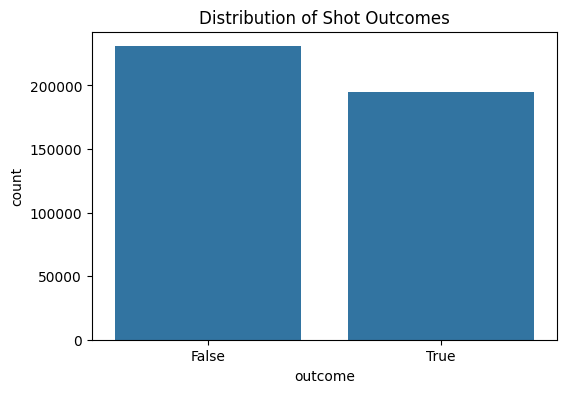

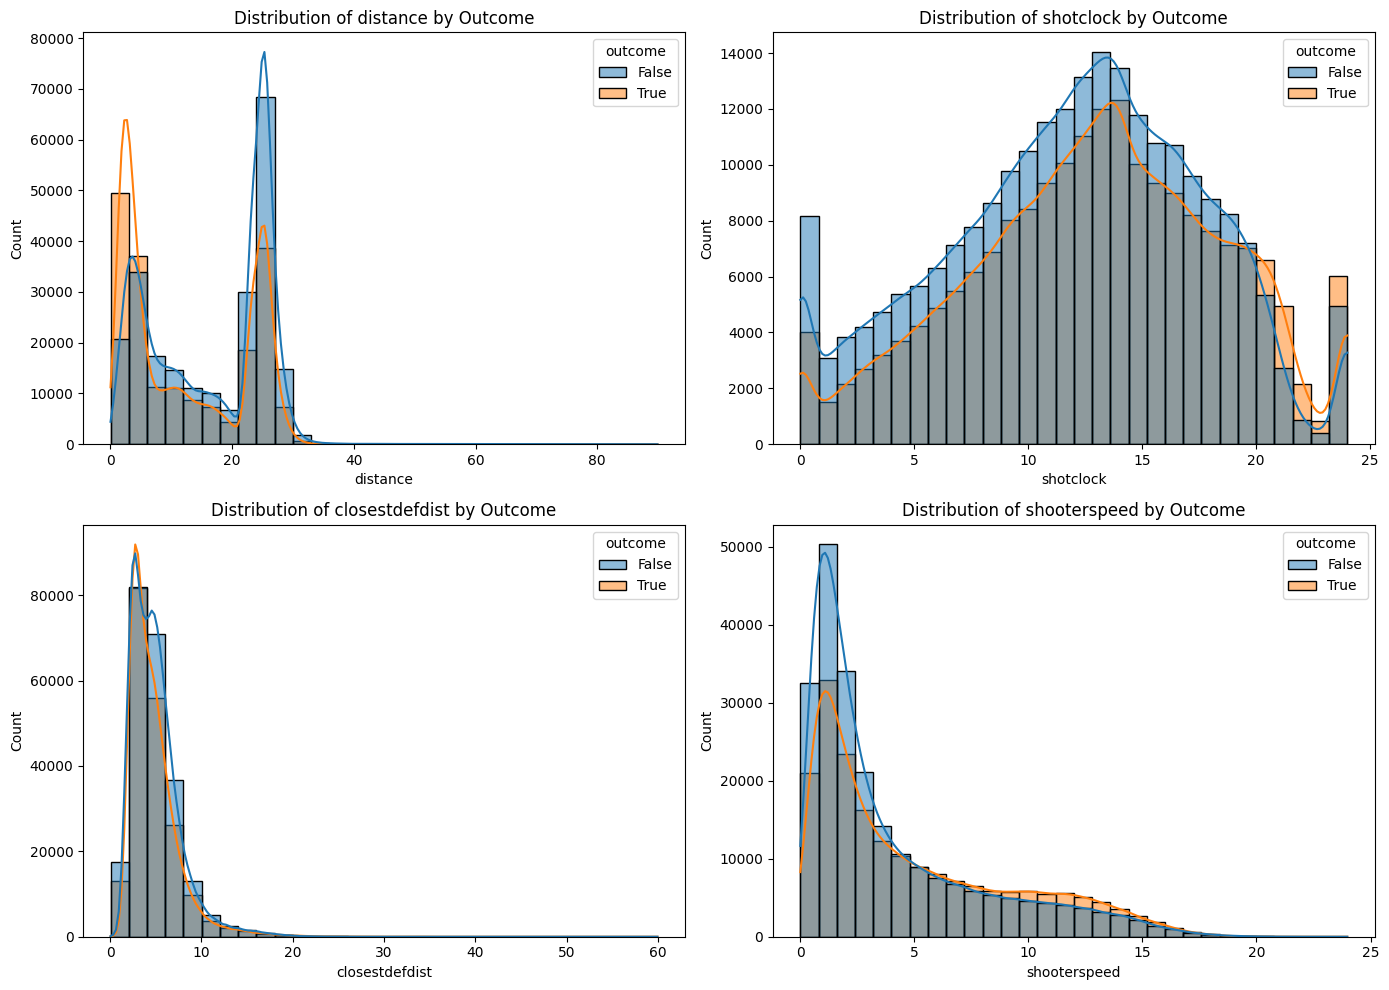

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot target variable
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='outcome')
plt.title('Distribution of Shot Outcomes')
plt.show()

# Key numerical features
num_features = ['distance', 'shotclock', 'closestdefdist', 'shooterspeed']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(num_features):
    sns.histplot(data=train_df, x=feature, hue='outcome', bins=30, ax=axes[i], kde=True)
    axes[i].set_title(f'Distribution of {feature} by Outcome')

plt.tight_layout()
plt.show()


I also looked at important categorical features to see whether some categories had different shot outcomes.


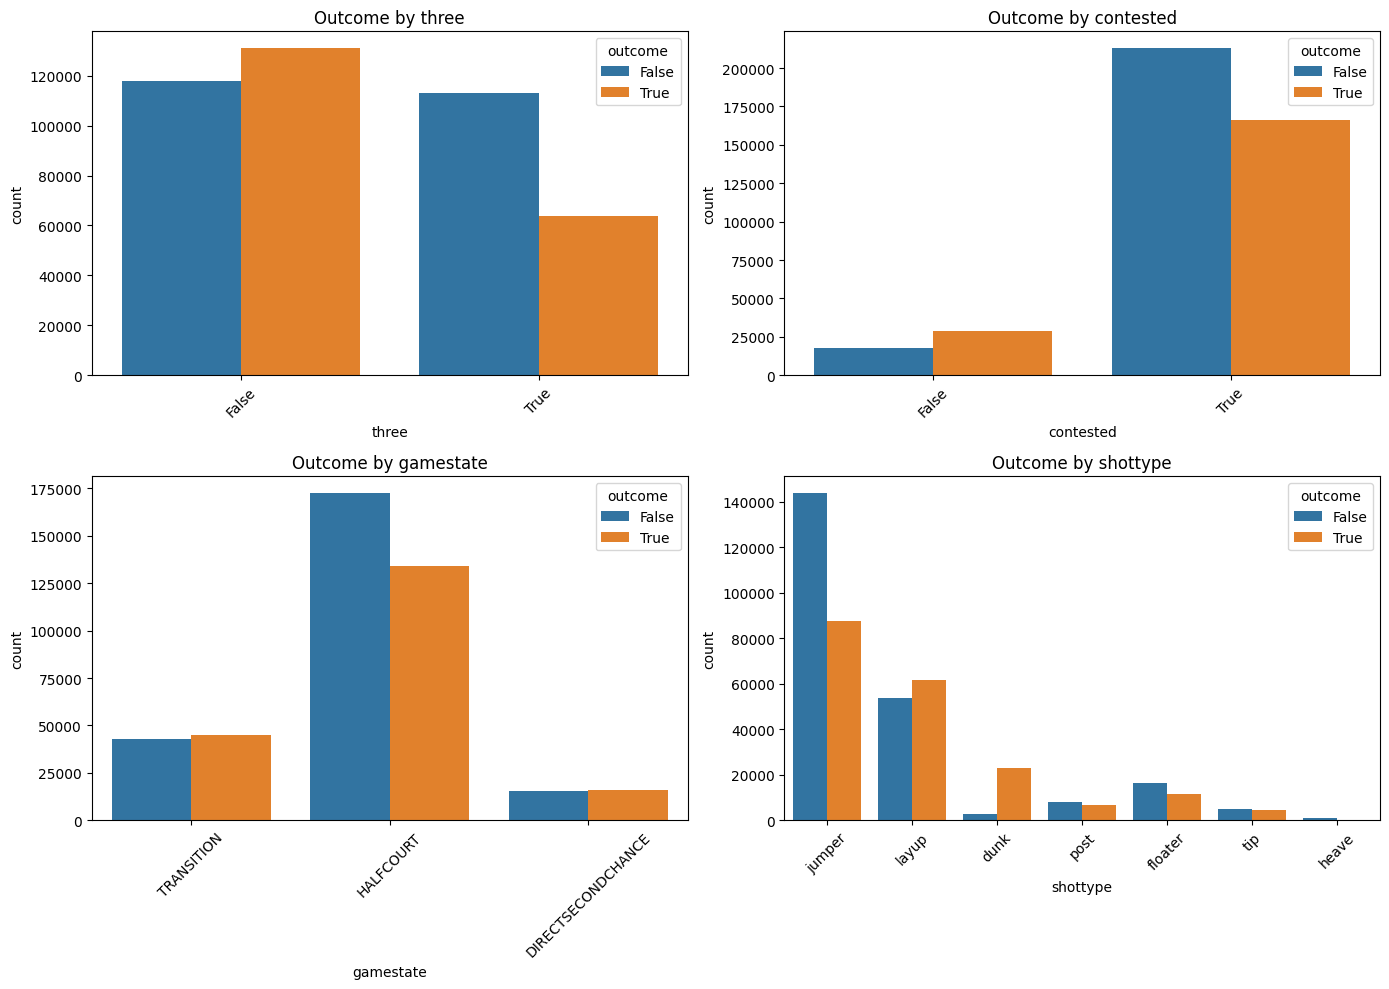

In [ ]:
cat_features = ['three', 'contested', 'gamestate', 'shottype']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(cat_features):
    sns.countplot(data=train_df, x=feature, hue='outcome', ax=axes[i])
    axes[i].set_title(f'Outcome by {feature}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Feature Engineering and Selection

Before training the models, the data needs to be converted into a fully numerical format. I removed ID columns that are not useful for prediction, converted numeric-looking columns to the correct type, changed boolean values to integers, and one-hot encoded categorical columns.


These preprocessing steps make the features suitable for machine-learning models. The same type of processing will later be applied to the test data so both datasets have matching features.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Drop high-cardinality IDs
cols_to_drop = ['shot_id', 'season_id', 'off_team_id', 'def_team_id', 'shooter_id',
                'closestdef_id', 'contester1_id', 'contester2_id', 'contester3_id', 'contester4_id']
train_df_cleaned = train_df.drop(columns=cols_to_drop)

# 2. Convert distcont columns to numeric
distcont_cols = ['distcont1', 'distcont2', 'distcont3', 'distcont4']
for col in distcont_cols:
    train_df_cleaned[col] = pd.to_numeric(train_df_cleaned[col], errors='coerce')
    train_df_cleaned[col] = train_df_cleaned[col].fillna(100.0) # Fill missing with 100 (far away)

# 3. Convert booleans to integers
bool_cols = train_df_cleaned.select_dtypes(include=['bool']).columns
for col in bool_cols:
    train_df_cleaned[col] = train_df_cleaned[col].astype(int)

# 4. One-hot encode remaining categoricals
cat_cols = ['month', 'gamestate', 'shottype']
train_df_encoded = pd.get_dummies(train_df_cleaned, columns=cat_cols, drop_first=True)

print(f"Shape after encoding: {train_df_encoded.shape}")
display(train_df_encoded.head())


Shape after encoding: (425719, 33)


,outcome,num_contesters,distcont1,distcont2,distcont3,distcont4,contested,distance,locationx,locationy,...,month_NOV,month_OCT,gamestate_HALFCOURT,gamestate_TRANSITION,shottype_floater,shottype_heave,shottype_jumper,shottype_layup,shottype_post,shottype_tip
0,0,0,100.000000,100.000000,100.0,100.0,0,24.794001,-21.91,14.87,...,False,False,False,True,False,False,True,False,False,False
1,1,1,2.969714,100.000000,100.0,100.0,1,16.458630,-34.91,-14.97,...,False,False,True,False,False,False,True,False,False,False
2,1,2,2.556345,2.694086,100.0,100.0,1,6.355289,-40.31,-6.19,...,False,False,True,False,False,False,False,True,False,False
3,1,0,100.000000,100.000000,100.0,100.0,0,2.310087,-39.61,-0.87,...,False,False,False,True,False,False,False,False,False,False
4,1,1,9.199810,100.000000,100.0,100.0,1,24.959908,-32.32,23.11,...,True,False,False,True,False,False,True,False,False,False


To reduce the number of features, I trained a Random Forest on a sample of the data and used its feature importance values. The most important features were then kept for the final models. Using a sample here makes this step faster and uses less memory.


Training Random Forest for feature selection...


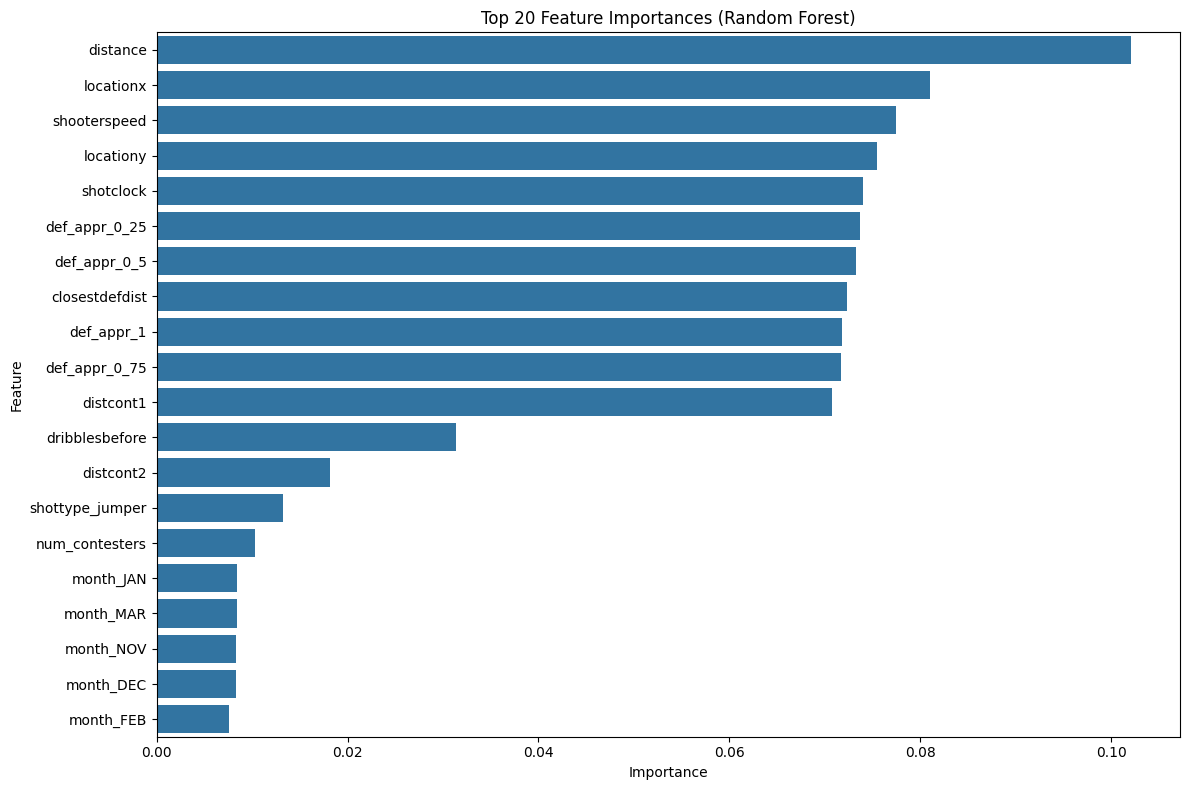

Selected Top 20 Features:
['distance', 'locationx', 'shooterspeed', 'locationy', 'shotclock', 'def_appr_0_25', 'def_appr_0_5', 'closestdefdist', 'def_appr_1', 'def_appr_0_75', 'distcont1', 'dribblesbefore', 'distcont2', 'shottype_jumper', 'num_contesters', 'month_JAN', 'month_MAR', 'month_NOV', 'month_DEC', 'month_FEB']
Final X shape: (425719, 20)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Separate features and target
X = train_df_encoded.drop('outcome', axis=1)
y = train_df_encoded['outcome']

# Use a sample to keep this step faster
sample_size = min(50000, len(X))
np.random.seed(42)
sample_indices = np.random.choice(len(X), sample_size, replace=False)
X_sample = X.iloc[sample_indices]
y_sample = y.iloc[sample_indices]

# Train Random Forest
print("Training Random Forest for feature selection...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_sample, y_sample)

# Get feature importances
importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance_df.head(20), x='Importance', y='Feature')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

# Keep the top 20 features
top_features = feature_importance_df.head(20)['Feature'].tolist()
print(f"Selected Top {len(top_features)} Features:\n{top_features}")

# Create final datasets with selected features
X_selected = X[top_features]
print(f"Final X shape: {X_selected.shape}")


## Model Training

I trained three classification models first: Logistic Regression, Random Forest, and XGBoost. The data was split into training and validation sets so the models could be compared on data they had not seen during training.


The numerical features were scaled where needed, and the same training and validation split was used for all three models to make the comparison fair.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Split data
print("Splitting data into train and validation sets...")
X_train, X_val, y_train, y_val = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)
print(f"X_train shape: {X_train.shape}, X_val shape: {X_val.shape}")

# Scale data
print("Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=15),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='logloss')
}

# Train models
print("Training models...")
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)

print("Training complete.")

Splitting data into train and validation sets...
X_train shape: (340575, 20), X_val shape: (85144, 20)
Scaling features...
Training models...
Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Training complete.


The first training setup was too heavy for the available memory and runtime. I reduced some model settings and used a smaller training sample so the models could finish without crashing the session. I also cleared unused objects from memory.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import gc

# Split data
print("Splitting data into train and validation sets...")
X_train, X_val, y_train, y_val = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)
print(f"X_train shape: {X_train.shape}, X_val shape: {X_val.shape}")

# Scale data
print("Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Free up some memory
del X_train
gc.collect()

# Use a smaller subset to avoid memory problems
sub_size = min(100000, X_train_scaled.shape[0])
X_train_sub = X_train_scaled[:sub_size]
y_train_sub = y_train[:sub_size]

# Use lighter settings to reduce memory and training time
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42, n_jobs=-1),
    'Random Forest': RandomForestClassifier(n_estimators=30, random_state=42, n_jobs=-1, max_depth=8),
    'XGBoost': XGBClassifier(n_estimators=50, random_state=42, n_jobs=-1, eval_metric='logloss', tree_method='hist')
}

# Train models
print(f"Training models on a subset of {sub_size} rows...")
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_sub, y_train_sub)
    gc.collect()  # Collect garbage after each model

print("Training complete.")

Splitting data into train and validation sets...
X_train shape: (340575, 20), X_val shape: (85144, 20)
Scaling features...
Training models on a subset of 100000 rows...
Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Training complete.


The previous run also produced too many warnings and logs. I ran the models again with unnecessary warnings hidden and XGBoost output reduced. This made the notebook easier to read without changing the main training process.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import gc
import warnings
warnings.filterwarnings('ignore')

# Split data
X_train, X_val, y_train, y_val = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Free up some memory
del X_train
gc.collect()

# Use a smaller subset to avoid memory problems
sub_size = min(100000, X_train_scaled.shape[0])
X_train_sub = X_train_scaled[:sub_size]
y_train_sub = y_train[:sub_size]

# Use lighter settings to reduce memory and training time
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42, n_jobs=-1),
    'Random Forest': RandomForestClassifier(n_estimators=30, random_state=42, n_jobs=-1, max_depth=8),
    'XGBoost': XGBClassifier(n_estimators=50, random_state=42, n_jobs=-1, eval_metric='logloss', tree_method='hist', verbosity=0)
}

# Train models
print(f"Training models on a subset of {sub_size} rows...")
for name, model in models.items():
    model.fit(X_train_sub, y_train_sub)
    gc.collect()  # Collect garbage after each model

print("Training complete.")

Training models on a subset of 100000 rows...
Training complete.


## Model Evaluation

The trained models were tested on the validation set using Accuracy, Precision, Recall, and F1-score. These metrics give a better picture than using accuracy alone.


For each model, I generated predictions on the validation data and calculated the four evaluation metrics. The results were stored in a DataFrame so they could be compared and plotted.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = []

print("Evaluating models on the validation set...")
for name, model in models.items():
    # Generate predictions
    y_pred = model.predict(X_val_scaled)

    # Calculate metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    # Store results
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1
    })

    print(f"--- {name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}\n")

# Create a DataFrame for easy visualization later
results_df = pd.DataFrame(results)
display(results_df)


Evaluating models on the validation set...
--- Logistic Regression ---
Accuracy:  0.6160
Precision: 0.6022
Recall:    0.4765
F1-score:  0.5320

--- Random Forest ---
Accuracy:  0.6317
Precision: 0.6817
Recall:    0.3675
F1-score:  0.4775

--- XGBoost ---
Accuracy:  0.6311
Precision: 0.6585
Recall:    0.4045
F1-score:  0.5011



,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.615992,0.602151,0.476540,0.532032
1,Random Forest,0.631671,0.681730,0.367468,0.477534
2,XGBoost,0.631107,0.658458,0.404492,0.501136


## Comparing the Model Results

The chart below compares Accuracy, Precision, Recall, and F1-score for the three models.


I reshaped the results table into a format that is easier to plot, then created a grouped bar chart so the strengths and weaknesses of each model could be seen more clearly.


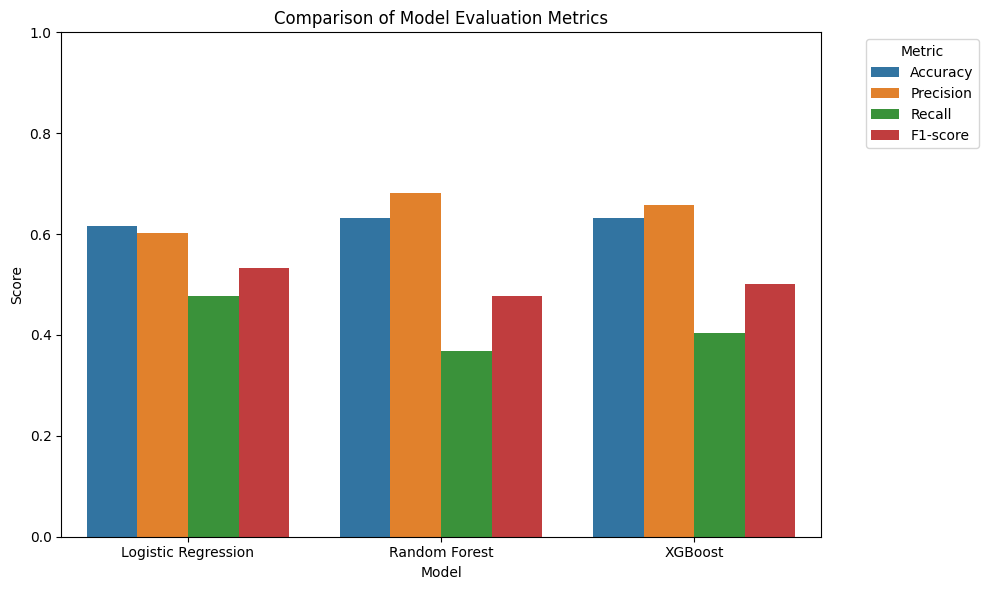

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reshape the results for plotting
results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Create the grouped bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric')

# Formatting the plot
plt.title('Comparison of Model Evaluation Metrics')
plt.ylim(0, 1) # Set y-axis limits from 0 to 1 for standard metric range
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## First Submission

After comparing the first three models, I used XGBoost to generate shot probabilities for the test data. The test dataset went through the same cleaning and feature-processing steps as the training data.


The test features were matched with the selected training features, scaled where required, and passed into the trained model. The predicted probability of making each shot was then saved in the required submission format.


In [ ]:
import polars as pl
import pandas as pd
import numpy as np
import re

# 1. Load testing data
print("Loading testing data...")
test_df = pl.read_csv('/content/testing.csv.gz').to_pandas()
shot_ids = test_df['shot_id'].copy()

# 2. Parse 'closestdefapproach'
def parse_approach(val):
    if pd.isna(val):
        return [np.nan, np.nan, np.nan, np.nan]
    floats = re.findall(r'[-+]?\d*\.\d+|[-+]?\d+', str(val))
    res = []
    for f in floats:
        try:
            res.append(float(f))
        except ValueError:
            pass
    if len(res) >= 4:
        return res[:4]
    else:
        return res + [np.nan] * (4 - len(res))

parsed_approaches_test = test_df['closestdefapproach'].apply(parse_approach)
approach_df_test = pd.DataFrame(parsed_approaches_test.tolist(), columns=['def_appr_1', 'def_appr_0_75', 'def_appr_0_5', 'def_appr_0_25'])
test_df = pd.concat([test_df, approach_df_test], axis=1)
test_df = test_df.drop('closestdefapproach', axis=1)

# Handle missing values
for col in test_df.columns:
    if test_df[col].dtype == 'object' or test_df[col].dtype == 'category':
        test_df[col] = test_df[col].fillna('Unknown')
    else:
        # Fill numeric with median
        test_df[col] = test_df[col].fillna(test_df[col].median())

# Drop high-cardinality IDs
cols_to_drop = ['shot_id', 'season_id', 'off_team_id', 'def_team_id', 'shooter_id',
                'closestdef_id', 'contester1_id', 'contester2_id', 'contester3_id', 'contester4_id']
test_df_cleaned = test_df.drop(columns=[c for c in cols_to_drop if c in test_df.columns])

# Convert distcont columns to numeric
distcont_cols = ['distcont1', 'distcont2', 'distcont3', 'distcont4']
for col in distcont_cols:
    test_df_cleaned[col] = pd.to_numeric(test_df_cleaned[col], errors='coerce')
    test_df_cleaned[col] = test_df_cleaned[col].fillna(100.0)

# Convert booleans to integers
bool_cols = test_df_cleaned.select_dtypes(include=['bool']).columns
for col in bool_cols:
    test_df_cleaned[col] = test_df_cleaned[col].astype(int)

# One-hot encode remaining categoricals
cat_cols = ['month', 'gamestate', 'shottype']
test_df_encoded = pd.get_dummies(test_df_cleaned, columns=cat_cols, drop_first=True)

# 3. Align features with training top_features
for col in top_features:
    if col not in test_df_encoded.columns:
        test_df_encoded[col] = 0 # Add missing one-hot encoded columns if any

X_test = test_df_encoded[top_features]

# 4. Scale features
print("Scaling test features...")
X_test_scaled = scaler.transform(X_test)

# 5. Predict probabilities
print("Generating predictions using XGBoost...")
best_model = models['XGBoost']
test_probs = best_model.predict_proba(X_test_scaled)[:, 1] # Probability of 'True' (make)

# 6 & 7. Create and save submission
submission = pd.DataFrame({
    'shot_id': shot_ids,
    'make_prob': test_probs
})

submission.to_csv('/content/submission.csv', index=False)
print("\nSubmission saved to /content/submission.csv")
display(submission.head())

Loading testing data...
Scaling test features...
Generating predictions using XGBoost...

Submission saved to /content/submission.csv


,shot_id,make_prob
0,1,0.356871
1,5,0.550285
2,6,0.467874
3,8,0.397219
4,10,0.368059


### First Version: Results and Reflection

**Model choice and performance**

For the first version of the project, I used **XGBoost** for the final prediction. XGBoost builds many decision trees, with each new tree trying to improve the mistakes made by the earlier trees.

On the validation set, XGBoost reached about **63.1% Accuracy**, **65.8% Precision**, **40.4% Recall**, and an **F1-score of 50.1%**. Random Forest had slightly higher precision, but XGBoost gave a reasonable balance between the different metrics and worked efficiently with `tree_method='hist'`.

**Important features**

A Random Forest feature-importance check was used to keep the top 20 features. Several of the most useful features were connected to shot position and game situation:

- `distance`, `locationx`, and `locationy` describe where the shot was taken from.
- `shooterspeed` and `shotclock` give information about the situation before the shot.
- `def_appr_0_25` and `def_appr_0_5` come from the defender approach data and give an idea of how close the nearest defender was before the shot.

**Problems I faced**

The main problem was the size of the dataset. Parsing `closestdefapproach` for more than 400,000 rows took a lot of memory and processing time. Some model runs also caused memory or timeout problems. To deal with this, I used smaller samples during some training steps, reduced model settings, and cleared unused memory with `gc.collect()`.

**Possible improvements**

The model could be improved by adding more basketball-related features, such as a player's previous shooting percentage, team offensive or defensive ratings, or a simple measure of fatigue such as minutes already played in the game.

**Submission**

The first set of predictions was saved to `/content/submission.csv` with the required `shot_id` and `make_prob` columns.


## Second Iteration: Improving the Model Comparison

After finishing the first version, I made another attempt to improve the workflow. I increased the amount of training data and added two more models: `ExtraTreesClassifier` and `HistGradientBoostingClassifier`. This allowed me to compare five models instead of three.


### Updated Model Training

The training subset was increased, and all five models were trained using the same selected features and validation setup.


For this second attempt, I used a larger training subset of 250,000 rows. The goal was to give the models more data while still keeping the notebook within the memory limits.


In [ ]:
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import gc
import warnings
warnings.filterwarnings('ignore')

# Increase the training subset size
sub_size = min(250000, X_train_scaled.shape[0])
X_train_sub = X_train_scaled[:sub_size]
y_train_sub = y_train[:sub_size]

# Initialize all five models
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42, n_jobs=-1),
    'Random Forest': RandomForestClassifier(n_estimators=30, random_state=42, n_jobs=-1, max_depth=8),
    'XGBoost': XGBClassifier(n_estimators=50, random_state=42, n_jobs=-1, eval_metric='logloss', tree_method='hist', verbosity=0),
    'Extra Trees': ExtraTreesClassifier(n_estimators=30, random_state=42, n_jobs=-1, max_depth=8),
    'HistGradientBoosting': HistGradientBoostingClassifier(max_iter=50, random_state=42)
}

# Train models
print(f"Training 5 models on a subset of {sub_size} rows...")
for name, model in models.items():
    model.fit(X_train_sub, y_train_sub)
    gc.collect()  # Collect garbage after each model

print("Training complete.")

Training 5 models on a subset of 250000 rows...
Training complete.


### Evaluating All Five Models

The same evaluation metrics were calculated again for Logistic Regression, Random Forest, XGBoost, Extra Trees, and HistGradientBoosting.


Using the same metrics for all five models makes it easier to see whether the extra models and larger training sample actually improved the results.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = []

print("Evaluating all 5 models on the validation set...")
for name, model in models.items():
    # Generate predictions
    y_pred = model.predict(X_val_scaled)

    # Calculate metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    # Store results
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1
    })

    print(f"--- {name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}\n")

# Create a DataFrame for easy visualization later
results_df = pd.DataFrame(results)
display(results_df)


Evaluating all 5 models on the validation set...
--- Logistic Regression ---
Accuracy:  0.6159
Precision: 0.6011
Recall:    0.4802
F1-score:  0.5339

--- Random Forest ---
Accuracy:  0.6315
Precision: 0.6819
Recall:    0.3666
F1-score:  0.4768

--- XGBoost ---
Accuracy:  0.6355
Precision: 0.6737
Recall:    0.3960
F1-score:  0.4988

--- Extra Trees ---
Accuracy:  0.6218
Precision: 0.6439
Recall:    0.3899
F1-score:  0.4857

--- HistGradientBoosting ---
Accuracy:  0.6370
Precision: 0.6845
Recall:    0.3852
F1-score:  0.4930



,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.615921,0.601104,0.480181,0.533881
1,Random Forest,0.631530,0.681929,0.366597,0.476846
2,XGBoost,0.635476,0.673749,0.395954,0.498781
3,Extra Trees,0.621770,0.643916,0.389929,0.485723
4,HistGradientBoosting,0.637038,0.684482,0.385185,0.492961


### Updated Comparison Chart

The grouped bar chart was updated to include all five models and the four evaluation metrics.


The results table was reshaped again and plotted so the five models could be compared side by side.


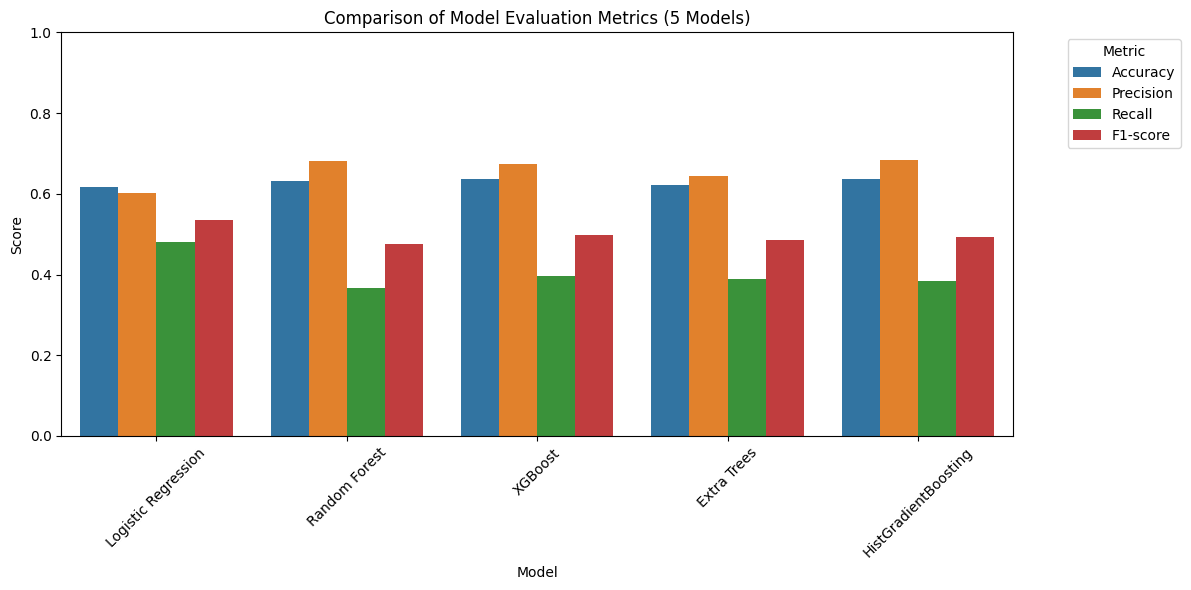

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reshape the results for plotting
results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Create the grouped bar chart
plt.figure(figsize=(12, 6))
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric')

# Formatting the plot
plt.title('Comparison of Model Evaluation Metrics (5 Models)')
plt.ylim(0, 1) # Set y-axis limits from 0 to 1 for standard metric range
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Updated Final Prediction

For the second iteration, the final model was selected using the highest F1-score. This metric was chosen because it considers both precision and recall.


After finding the model with the highest F1-score, I used that trained model to predict the shot probabilities for the test set and replaced the earlier submission predictions.


In [ ]:
import pandas as pd

# Choose the model with the highest F1-score
best_model_row = results_df.loc[results_df['F1-score'].idxmax()]
best_model_name = best_model_row['Model']
print(f"Best model selected: {best_model_name} (F1-score: {best_model_row['F1-score']:.4f})")

# 2. Extract the best model
best_model = models[best_model_name]

# 3. Predict probabilities on test set
print("Generating new predictions for the test dataset...")
new_test_probs = best_model.predict_proba(X_test_scaled)[:, 1]

# 4. Update the submission DataFrame
submission['make_prob'] = new_test_probs

# 5. Save the updated submission
submission.to_csv('/content/submission.csv', index=False)
print("\nUpdated submission saved to /content/submission.csv")
display(submission.head())

Best model selected: Logistic Regression (F1-score: 0.5339)
Generating new predictions for the test dataset...

Updated submission saved to /content/submission.csv


,shot_id,make_prob
0,1,0.346754
1,5,0.601399
2,6,0.587006
3,8,0.563532
4,10,0.365653


### Second Iteration: Results

The second version used a larger training subset of **250,000 rows** and added `ExtraTreesClassifier` and `HistGradientBoostingClassifier`.

After testing all five models:

- **HistGradientBoosting** had the highest Accuracy at about **63.7%** and the highest Precision at about **68.4%**.
- **Logistic Regression** had the highest F1-score at about **53.4%** and the highest Recall at about **48.0%**.

Since I used F1-score as the main metric for choosing the final model, **Logistic Regression** was selected for the updated submission. This was different from the first version, where XGBoost was used.

The new `make_prob` predictions were generated with Logistic Regression and saved again to `/content/submission.csv` with the required `shot_id` and `make_prob` columns.


## Final Reflection

The second iteration improved the project by testing more models and using more training data. Adding Extra Trees and HistGradientBoosting gave a wider comparison, but the more complex models were not automatically better for every metric.

HistGradientBoosting gave the best Accuracy and Precision, while Logistic Regression gave the best Recall and F1-score. Because the final selection was based on F1-score, Logistic Regression became the final model.

One useful lesson from this is that a simpler model can still perform well when the selected features already contain useful information. The results also show why it is important to compare several metrics instead of choosing a model only from Accuracy.

If I continued improving the project, I would test interaction features and other non-linear transformations. I would also try combining models, for example by stacking Logistic Regression with HistGradientBoosting, to see if their different strengths could improve the overall result.
